In [2]:
import pandas as pd
import sqlalchemy as sa

In [3]:
from sqlalchemy import create_engine, text

# Replace with your credentials
server = 'exusbigcloud.database.windows.net'
database = 'bigcloud_db'
username = 'exusbigcloud_admin'
password = '7t>Oj038U&%s'  # Replace with your actual password

# SQLAlchemy connection string using pymssql
connection_string = (
    f"mssql+pymssql://{username}:{password}@{server}:1433/{database}"
)

engine = create_engine(connection_string)


In [4]:
df_demanda = pd.read_sql("SELECT * FROM EuropeDemandActuals WHERE PriceAreaCode = 'ES' AND Type = 'actual' AND Resolution = 'PT15M' AND LocalTime >= '2025-01-01 00:00:00+02:00' AND LocalTime < '2025-06-01 00:00:00+02:00'", engine)
df_demanda

,CountryCode,PriceAreaCode,Type,Quantity,Unit,Resolution,LocalTime,UTCTime,id
0,ES,ES,actual,23108.0,MW,PT15M,2025-01-01 00:15:00+01:00,2024-12-31 23:15:00+00:00,BZN|ES_actual_PT15M_2024-12-31 23:15:00+00:00
1,ES,ES,actual,22976.0,MW,PT15M,2025-01-01 00:30:00+01:00,2024-12-31 23:30:00+00:00,BZN|ES_actual_PT15M_2024-12-31 23:30:00+00:00
2,ES,ES,actual,22852.0,MW,PT15M,2025-01-01 00:45:00+01:00,2024-12-31 23:45:00+00:00,BZN|ES_actual_PT15M_2024-12-31 23:45:00+00:00
3,ES,ES,actual,22712.0,MW,PT15M,2025-01-01 01:00:00+01:00,2025-01-01 00:00:00+00:00,BZN|ES_actual_PT15M_2025-01-01 00:00:00+00:00
4,ES,ES,actual,22540.0,MW,PT15M,2025-01-01 01:15:00+01:00,2025-01-01 00:15:00+00:00,BZN|ES_actual_PT15M_2025-01-01 00:15:00+00:00
...,...,...,...,...,...,...,...,...,...
14485,ES,ES,actual,27308.0,MW,PT15M,2025-05-31 22:45:00+02:00,2025-05-31 20:45:00+00:00,BZN|ES_actual_PT15M_2025-05-31 20:45:00+00:00
14486,ES,ES,actual,26880.0,MW,PT15M,2025-05-31 23:00:00+02:00,2025-05-31 21:00:00+00:00,BZN|ES_actual_PT15M_2025-05-31 21:00:00+00:00
14487,ES,ES,actual,26364.0,MW,PT15M,2025-05-31 23:15:00+02:00,2025-05-31 21:15:00+00:00,BZN|ES_actual_PT15M_2025-05-31 21:15:00+00:00
14488,ES,ES,actual,25828.0,MW,PT15M,2025-05-31 23:30:00+02:00,2025-05-31 21:30:00+00:00,BZN|ES_actual_PT15M_2025-05-31 21:30:00+00:00


In [5]:
df_demanda 
df_demanda[df_demanda['Quantity'] < 1000]

,CountryCode,PriceAreaCode,Type,Quantity,Unit,Resolution,LocalTime,UTCTime,id
3475,ES,ES,actual,368.0,MW,PT15M,2025-02-06 05:00:00+01:00,2025-02-06 04:00:00+00:00,BZN|ES_actual_PT15M_2025-02-06 04:00:00+00:00
3477,ES,ES,actual,176.0,MW,PT15M,2025-02-06 05:30:00+01:00,2025-02-06 04:30:00+00:00,BZN|ES_actual_PT15M_2025-02-06 04:30:00+00:00
3491,ES,ES,actual,160.0,MW,PT15M,2025-02-06 09:00:00+01:00,2025-02-06 08:00:00+00:00,BZN|ES_actual_PT15M_2025-02-06 08:00:00+00:00
3862,ES,ES,actual,108.0,MW,PT15M,2025-02-10 05:45:00+01:00,2025-02-10 04:45:00+00:00,BZN|ES_actual_PT15M_2025-02-10 04:45:00+00:00
8706,ES,ES,actual,0.0,MW,PT15M,2025-04-01 17:45:00+02:00,2025-04-01 15:45:00+00:00,BZN|ES_actual_PT15M_2025-04-01 15:45:00+00:00
8707,ES,ES,actual,0.0,MW,PT15M,2025-04-01 18:00:00+02:00,2025-04-01 16:00:00+00:00,BZN|ES_actual_PT15M_2025-04-01 16:00:00+00:00
8711,ES,ES,actual,0.0,MW,PT15M,2025-04-01 19:00:00+02:00,2025-04-01 17:00:00+00:00,BZN|ES_actual_PT15M_2025-04-01 17:00:00+00:00
8740,ES,ES,actual,0.0,MW,PT15M,2025-04-02 02:15:00+02:00,2025-04-02 00:15:00+00:00,BZN|ES_actual_PT15M_2025-04-02 00:15:00+00:00
8741,ES,ES,actual,0.0,MW,PT15M,2025-04-02 02:30:00+02:00,2025-04-02 00:30:00+00:00,BZN|ES_actual_PT15M_2025-04-02 00:30:00+00:00
8742,ES,ES,actual,0.0,MW,PT15M,2025-04-02 02:45:00+02:00,2025-04-02 00:45:00+00:00,BZN|ES_actual_PT15M_2025-04-02 00:45:00+00:00


In [6]:
df_outages_raw = pd.read_sql("SELECT * FROM EuropeOutagesActuals WHERE PriceAreaCode = 'ES' AND Type = 'Planned' AND Resolution = 'PT15M'", engine)

In [7]:
df_outages = df_outages_raw.copy()
df_outages['LocalTime'] = pd.to_datetime(df_outages['LocalTime'], utc=True)
df_outages['date'] = df_outages['LocalTime'].dt.date
df_outages_filtered = df_outages[df_outages['LocalTime'] == '2020-01-20 20:00:00+01:00']

df_outages_filtered
(df_outages_filtered['TotalQuantity'] - df_outages_filtered['AvailableQuantity']).sum()

df_outages_filtered

,CountryCode,PriceAreaCode,Technology,Type,AvailableQuantity,TotalQuantity,Unit,Resolution,LocalTime,UTCTime,id,date
1822,ES,ES,Fossil Gas,Planned,410.2,820.5,MW,PT15M,2020-01-20 19:00:00+00:00,2020-01-20 19:00:00+00:00,ES_PT15M_Fossil Gas_Planned_2020-01-20 19:00:0...,2020-01-20
9882,ES,ES,Hydro Pumped Storage,Planned,1170.0,1728.0,MW,PT15M,2020-01-20 19:00:00+00:00,2020-01-20 19:00:00+00:00,ES_PT15M_Hydro Pumped Storage_Planned_2020-01-...,2020-01-20
14874,ES,ES,Hydro Water Reservoir,Planned,6817.4,8023.0,MW,PT15M,2020-01-20 19:00:00+00:00,2020-01-20 19:00:00+00:00,ES_PT15M_Hydro Water Reservoir_Planned_2020-01...,2020-01-20


In [8]:
from datetime import datetime
import numpy as np
dict_day = {
    '21 Jan 2020': datetime(2020, 1, 21).date(),
    '13 Jan 2021': datetime(2021, 1, 13).date(),
    '14 Jul 2022': datetime(2022, 7, 14).date(),
    '19 Jul 2023': datetime(2023, 7, 19).date(),
    '10 Jan 2024': datetime(2024, 1, 10).date()
}

list_instants = [datetime(2020, 1, 20, 19, 0, 0),
                 datetime(2021, 1, 8, 12, 0, 0),
                 datetime(2022, 7, 14, 12, 15, 0),
                 datetime(2023, 1, 24, 19, 30, 0),
                 datetime(2024, 1, 9, 20, 0, 0)]

In [10]:
# en esta celda calculamos los outages medios por tecnología en las fechas de interés

from datetime import date

df_outages['date'] = df_outages['LocalTime'].dt.date
df_outages_filtered = df_outages[df_outages['date'].isin(dict_day.values())]
df_outages_filtered.sort_values(by='LocalTime', inplace=True)
df_outages_filtered

df_outages_filtered['outage'] = df_outages_filtered['TotalQuantity'] - df_outages_filtered['AvailableQuantity']

df2 = df_outages_filtered.groupby(['date', 'Technology'])['outage'].mean().reset_index()

df2_pivot = df2.pivot(index='date', columns='Technology', values='outage').fillna(0)

df2_pivot

C:\Users\mpy\AppData\Local\Temp\ipykernel_34456\521781656.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_outages_filtered.sort_values(by='LocalTime', inplace=True)
C:\Users\mpy\AppData\Local\Temp\ipykernel_34456\521781656.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_outages_filtered['outage'] = df_outages_filtered['TotalQuantity'] - df_outages_filtered['AvailableQuantity']


Technology,Fossil Gas,Fossil Hard coal,Hydro Pumped Storage,Hydro Water Reservoir
date,,,,
2020-01-21,410.3,0.0,658.0,1315.4
2021-01-13,0.0,347.4,433.0,851.1
2022-07-14,305.2,0.0,876.0,3391.9
2023-07-19,0.0,0.0,957.9,2979.4
2024-01-10,0.0,0.0,425.8,405.2


In [28]:
from datetime import time

list_instants = [datetime(2020, 1, 20, 19, 0, 0,0),
                 datetime(2021, 1, 8, 12, 0, 0),
                 datetime(2022, 7, 14, 12, 15, 0),
                 datetime(2023, 1, 24, 19, 30, 0),
                 datetime(2024, 1, 9, 20, 0, 0)]

df_outages_instants = df_outages.copy()
df_outages_instants['hour'] = df_outages_instants['LocalTime'].dt.hour
df_outages_instants['minute'] = df_outages_instants['LocalTime'].dt.minute
df_outages_instants['outage'] = df_outages_instants['TotalQuantity'] - df_outages_instants['AvailableQuantity']
df_outages_instants['datetime'] = df_outages_instants.apply(lambda row: datetime.combine(row['date'], time(row['hour'], row['minute'])), axis=1)
df_outages_instants_filtered = df_outages_instants[(df_outages_instants['datetime'].isin(list_instants))]

df_outages_instants_filtered.pivot(index='datetime', columns='Technology', values='outage').fillna(0)

Technology,Fossil Gas,Fossil Hard coal,Hydro Pumped Storage,Hydro Water Reservoir
datetime,,,,
2020-01-20 19:00:00,410.3,0.0,558.0,1205.6
2021-01-08 12:00:00,0.0,347.4,433.0,803.9
2022-07-14 12:15:00,305.2,0.0,876.0,3391.9
2023-01-24 19:30:00,786.4,0.0,968.0,1956.7
2024-01-09 20:00:00,0.0,0.0,425.8,405.2


In [ ]:
# df_links = pd.read_sql("SELECT * FROM EuropeInterconnectionActuals WHERE (CountryCodeTo = 'ES' OR  CountryCodeFrom = 'ES') AND LocalTime >= '2024-01-01 00:00:00+02:00' AND LocalTime < '2025-01-01 00:00:00+02:00'", engine)

In [32]:
# df_links['CountryCodeFrom'].unique()
# print(df_links[df_links['Resolution'] == 'PT15M']['CountryCodeFrom'].unique())
# print(df_links[df_links['Resolution'] == 'PT15M']['CountryCodeTo'].unique())

['ES' 'FR']
['FR' 'ES']


In [43]:
# df_links['LocalTime'] = pd.to_datetime(df_links['LocalTime'], utc=True)
# df_links[(df_links['Resolution'] == 'PT15M') & (df_links['CountryCodeFrom'] == 'FR') & (df_links['CountryCodeTo'] == 'ES') & (df_links['LocalTime'].dt.month == 10)]['Quantity'].sum() / 4

np.float64(707687.25)

In [33]:
df_links['flow'] = df_links.apply(lambda row: f"{row['CountryCodeFrom']}_to_{row['CountryCodeTo']}", axis=1)

# df_links_pivot = df_links[['LocalTime', 'flow', 'Quantity']].pivot(index='LocalTime', columns='flow', values='Quantity')
df_links['flow'].unique()

array(['ES_to_FR', 'ES_to_PT', 'FR_to_ES', 'PT_to_ES', 'ES_to_MA',
       'MA_to_ES'], dtype=object)

In [7]:
df_demanda['LocalTime'] = pd.to_datetime(df_demanda['LocalTime'], utc=True)
df_demanda[df_demanda['LocalTime'].dt.month == 10]['Quantity'].sum() / 4
df_demanda[df_demanda['LocalTime'].dt.month == 10]

,CountryCode,PriceAreaCode,Type,Quantity,Unit,Resolution,LocalTime,UTCTime,id
26307,ES,ES,actual,22132.0,MW,PT15M,2024-10-01 00:00:00+00:00,2024-10-01 00:00:00+00:00,BZN|ES_actual_PT15M_2024-10-01 00:00:00+00:00
26308,ES,ES,actual,21812.0,MW,PT15M,2024-10-01 00:15:00+00:00,2024-10-01 00:15:00+00:00,BZN|ES_actual_PT15M_2024-10-01 00:15:00+00:00
26309,ES,ES,actual,21608.0,MW,PT15M,2024-10-01 00:30:00+00:00,2024-10-01 00:30:00+00:00,BZN|ES_actual_PT15M_2024-10-01 00:30:00+00:00
26310,ES,ES,actual,21544.0,MW,PT15M,2024-10-01 00:45:00+00:00,2024-10-01 00:45:00+00:00,BZN|ES_actual_PT15M_2024-10-01 00:45:00+00:00
26311,ES,ES,actual,21360.0,MW,PT15M,2024-10-01 01:00:00+00:00,2024-10-01 01:00:00+00:00,BZN|ES_actual_PT15M_2024-10-01 01:00:00+00:00
...,...,...,...,...,...,...,...,...,...
29277,ES,ES,actual,23836.0,MW,PT15M,2024-10-31 22:45:00+00:00,2024-10-31 22:45:00+00:00,BZN|ES_actual_PT15M_2024-10-31 22:45:00+00:00
29278,ES,ES,actual,23320.0,MW,PT15M,2024-10-31 23:00:00+00:00,2024-10-31 23:00:00+00:00,BZN|ES_actual_PT15M_2024-10-31 23:00:00+00:00
29279,ES,ES,actual,22884.0,MW,PT15M,2024-10-31 23:15:00+00:00,2024-10-31 23:15:00+00:00,BZN|ES_actual_PT15M_2024-10-31 23:15:00+00:00
29280,ES,ES,actual,22692.0,MW,PT15M,2024-10-31 23:30:00+00:00,2024-10-31 23:30:00+00:00,BZN|ES_actual_PT15M_2024-10-31 23:30:00+00:00


In [32]:
df_gen = pd.read_sql("SELECT * FROM EuropeGenerationActuals WHERE PriceAreaCode = 'ES' AND Resolution = 'PT15M' AND LocalTime >= '2024-01-01 00:00:00+02:00' AND LocalTime < '2025-01-01 00:00:00+02:00'", engine)

In [37]:
df_gen[df_gen['LocalTime'].dt.month == 10]

,CountryCode,PriceAreaCode,Technology,Quantity,Unit,Resolution,LocalTime,UTCTime,id
11385,ES,ES,Biomass,396.0,MW,PT15M,2024-10-01 00:00:00+00:00,2024-10-01 00:00:00+00:00,ES_PT15M_Biomass_2024-10-01 00:00:00+00:00
11386,ES,ES,Biomass,396.0,MW,PT15M,2024-10-01 00:15:00+00:00,2024-10-01 00:15:00+00:00,ES_PT15M_Biomass_2024-10-01 00:15:00+00:00
11387,ES,ES,Biomass,400.0,MW,PT15M,2024-10-01 00:30:00+00:00,2024-10-01 00:30:00+00:00,ES_PT15M_Biomass_2024-10-01 00:30:00+00:00
11388,ES,ES,Biomass,396.0,MW,PT15M,2024-10-01 00:45:00+00:00,2024-10-01 00:45:00+00:00,ES_PT15M_Biomass_2024-10-01 00:45:00+00:00
11389,ES,ES,Biomass,400.0,MW,PT15M,2024-10-01 01:00:00+00:00,2024-10-01 01:00:00+00:00,ES_PT15M_Biomass_2024-10-01 01:00:00+00:00
...,...,...,...,...,...,...,...,...,...
320983,ES,ES,Wind_Onshore,4932.0,MW,PT15M,2024-10-31 22:45:00+00:00,2024-10-31 22:45:00+00:00,ES_PT15M_Wind_Onshore_2024-10-31 22:45:00+00:00
320984,ES,ES,Wind_Onshore,4836.0,MW,PT15M,2024-10-31 23:00:00+00:00,2024-10-31 23:00:00+00:00,ES_PT15M_Wind_Onshore_2024-10-31 23:00:00+00:00
320985,ES,ES,Wind_Onshore,4740.0,MW,PT15M,2024-10-31 23:15:00+00:00,2024-10-31 23:15:00+00:00,ES_PT15M_Wind_Onshore_2024-10-31 23:15:00+00:00
320986,ES,ES,Wind_Onshore,4632.0,MW,PT15M,2024-10-31 23:30:00+00:00,2024-10-31 23:30:00+00:00,ES_PT15M_Wind_Onshore_2024-10-31 23:30:00+00:00


In [38]:
df_gen['LocalTime'] = pd.to_datetime(df_gen['LocalTime'], utc=True)
df_gen[df_gen['LocalTime'].dt.month == 10]['Quantity'].sum() / 4
# df_gen

np.float64(20838404.0)

In [34]:
df_gen_pivotted = df_gen.pivot_table(index='LocalTime', columns='Technology', values='Quantity').reset_index()

df_gen_pivotted['LocalTime'] = pd.to_datetime(df_gen_pivotted['LocalTime'], utc=True)

df_gen_pivotted[df_gen_pivotted['LocalTime'].dt.month == 10]['Hydro_RES'].sum() / 4
df_gen_pivotted

Technology,LocalTime,Biomass,Coal_Hard,Coal_Soft,Gas_All,Geothermal,Hydro_PS,Hydro_RES,Hydro_RoR,Marine,Nuclear,Oil,Other,Solar_All,Waste,Wind_Offshore,Wind_Onshore
0,2023-12-31 23:15:00+00:00,244.0,280.0,0.0,4452.0,0.0,1840.0,2160.0,1004.0,0.0,7096.0,20.0,76.0,28.0,240.0,0.0,5380.0
1,2023-12-31 23:30:00+00:00,252.0,280.0,0.0,4428.0,0.0,1508.0,2144.0,1008.0,0.0,7096.0,20.0,76.0,28.0,244.0,0.0,5536.0
2,2023-12-31 23:45:00+00:00,248.0,280.0,0.0,4316.0,0.0,1424.0,2104.0,1008.0,0.0,7096.0,20.0,76.0,28.0,248.0,0.0,5624.0
3,2024-01-01 00:00:00+00:00,244.0,280.0,0.0,4268.0,0.0,1380.0,2000.0,996.0,0.0,7096.0,20.0,76.0,28.0,248.0,0.0,5632.0
4,2024-01-01 00:15:00+00:00,240.0,276.0,0.0,4380.0,0.0,1348.0,2052.0,960.0,0.0,7096.0,20.0,76.0,28.0,248.0,0.0,5664.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35128,2024-12-31 22:00:00+00:00,392.0,508.0,0.0,9900.0,0.0,156.0,1968.0,956.0,0.0,7116.0,8.0,84.0,4.0,180.0,0.0,2644.0
35129,2024-12-31 22:15:00+00:00,392.0,504.0,0.0,9780.0,0.0,156.0,1796.0,920.0,0.0,7116.0,8.0,84.0,4.0,184.0,0.0,2724.0
35130,2024-12-31 22:30:00+00:00,388.0,508.0,0.0,9228.0,0.0,176.0,1808.0,948.0,0.0,7116.0,8.0,84.0,4.0,184.0,0.0,2776.0
35131,2024-12-31 22:45:00+00:00,388.0,508.0,0.0,8892.0,0.0,148.0,1820.0,944.0,0.0,7116.0,8.0,84.0,4.0,180.0,0.0,2812.0


In [35]:
df_merged = pd.merge(df_gen_pivotted, df_demanda[['LocalTime', 'Quantity']], on='LocalTime', how='left')
df_merged

ValueError: You are trying to merge on datetime64[ns, UTC] and object columns for key 'LocalTime'. If you wish to proceed you should use pd.concat

In [ ]:
df_hourly_avg = df_gen_pivotted.groupby(df_gen_pivotted['LocalTime'].dt.hour).mean()
df_hourly_avg.drop(columns=['LocalTime'], inplace=True)
df_hourly_avg['totals'] = df_hourly_avg.sum(axis=1)

for col in df_hourly_avg.columns:
    df_hourly_avg[col + '_perc'] = df_hourly_avg[col] / df_hourly_avg['totals']


# df_hourly_avg.to_excel('gen_by_technology_hourly_avg_2024.xlsx')

<Axes: xlabel='LocalTime'>

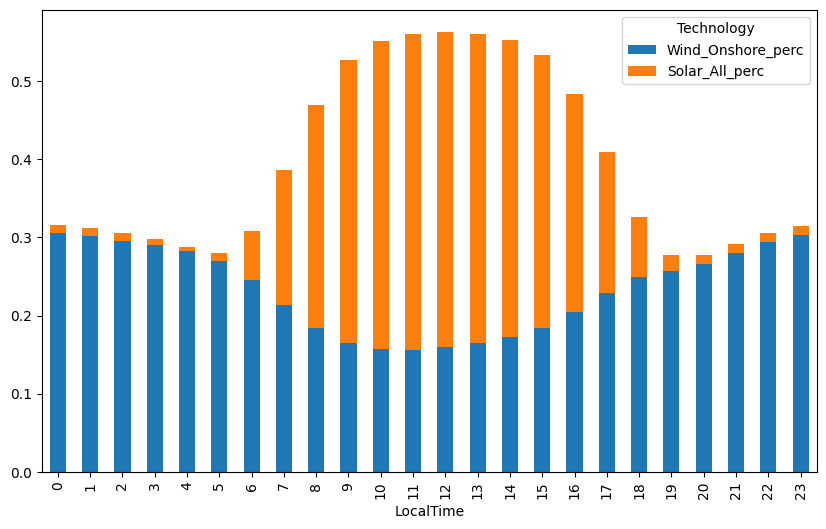

In [ ]:
import matplotlib.pyplot as plt

df_hourly_avg[['Wind_Onshore_perc', 'Solar_All_perc']].plot(kind='bar', stacked=True, figsize=(10, 6))

In [ ]:
for col in df_merged.columns:
    if col != 'LocalTime' and col != 'Quantity':
        df_merged[col + '_perc'] = df_merged[col] / df_merged['Quantity']

df_merged_hourly_avg = df_merged.groupby(df_merged['LocalTime'].dt.hour).mean()


<Axes: xlabel='LocalTime'>

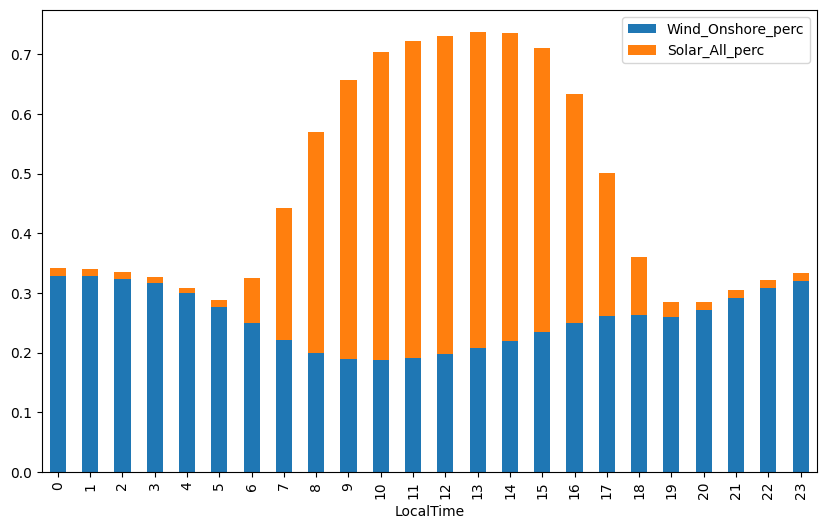

In [ ]:
df_merged_hourly_avg[['Wind_Onshore_perc', 'Solar_All_perc']].plot(kind='bar', stacked=True, figsize=(10, 6))